In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skew

In [8]:
value = fetch_california_housing()
vals = value.data
targ = value.target
targ_n = value.target_names
names = value.feature_names

In [21]:
dataset = pd.DataFrame(vals, columns=names)
dataset["MedHouseVal"] = targ
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [50]:
val_train, val_test, targ_train, targ_test = train_test_split(vals, targ, test_size=.2, random_state=42)

In [51]:
edit = pd.DataFrame(val_train)
edit.columns = names
edit['MedHouseVal'] = targ_train
edit.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [52]:
scaler = StandardScaler()
val_sc = scaler.fit_transform(val_train)

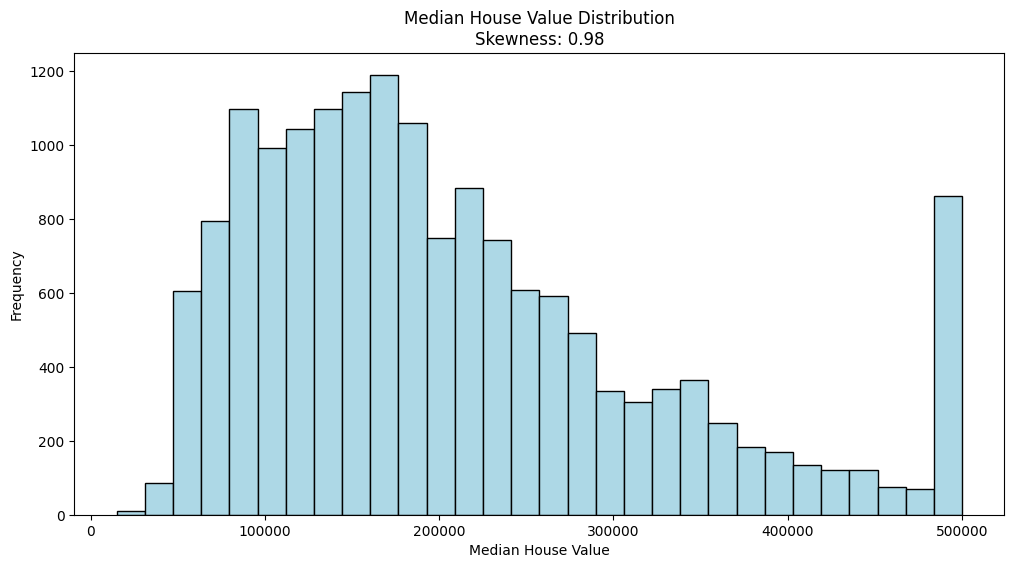

In [53]:
plt.figure(figsize=(12, 6))
plt.hist(1e5*targ_train, bins=30, color='lightblue', edgecolor='black')
plt.title("Median House Value Distribution\nSkewness: %.2f" %skew(targ_train))
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

In [63]:
rfregressor = RandomForestRegressor(n_estimators=100, random_state=42)
rfregressor.fit(val_train, targ_train)

targ_pred = rfregressor.predict(val_test)

In [64]:
mae = mean_absolute_error(targ_test, targ_pred)
mse = mean_squared_error(targ_test, targ_pred)
rmse = root_mean_squared_error(targ_test, targ_pred)
r2 = r2_score(targ_test, targ_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2556
Root Mean Squared Error (RMSE): 0.5055
R² Score: 0.8050


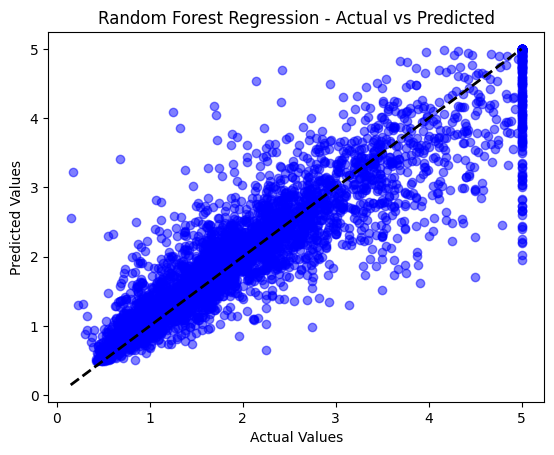

In [76]:
plt.scatter(targ_test, targ_pred, alpha=0.5, color="blue")
plt.plot([targ_test.min(), targ_test.max()], [targ_test.min(), targ_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

Mean of Residuals:  -1214
Standard Deviation of Residuals:  50537


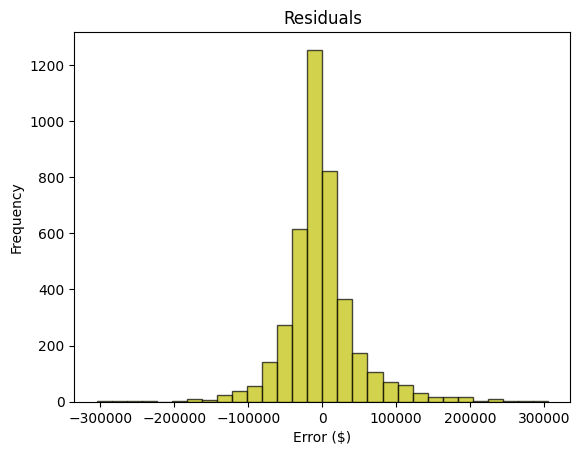

In [95]:
residue = 1e5*(targ_test - targ_pred)
plt.hist(residue, bins=30, alpha=0.7, color="y", edgecolor="k")
plt.title("Residuals")
plt.xlabel("Error ($)")
plt.ylabel("Frequency")

print("Mean of Residuals: ", str(int(np.mean(residue))))
print("Standard Deviation of Residuals: ", str(int(np.std(residue))))

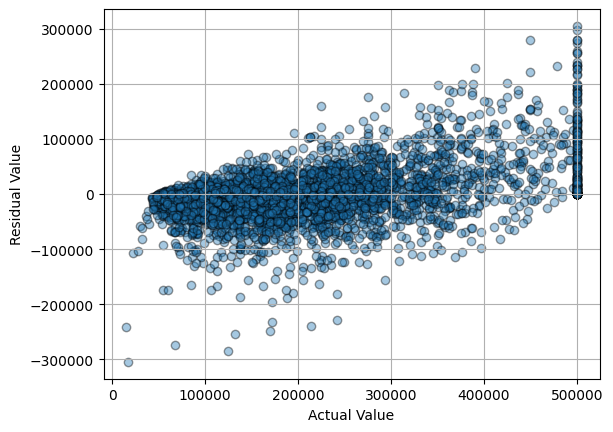

In [106]:
residue = 1e5*(targ_test - targ_pred)
res_dataframe = pd.DataFrame({
    "Actuals": 1e5*targ_test,
    "Residuals": residue
})

res_dataframe.sort_values(by="Actuals", ascending=True)

plt.scatter(res_dataframe["Actuals"], res_dataframe["Residuals"], marker="o", edgecolor="k", alpha=0.4)
plt.ylabel("Residual Value")
plt.xlabel("Actual Value")
plt.grid(True)
plt.show()

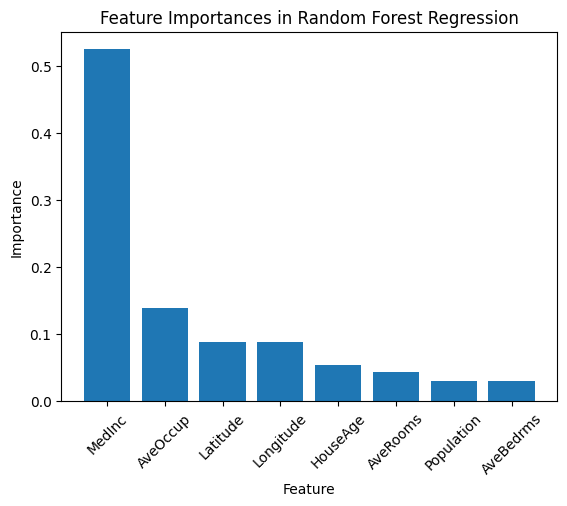

In [108]:
importances = rfregressor.feature_importances_
indices = np.argsort(importances)[::-1] 

plt.bar(range(vals.shape[1]), importances[indices], align="center")
plt.xticks(range(vals.shape[1]), [names[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()